# day 25 | 251027 M

## herein

Today we will continue in our study of differential equations by looking at exercise 8.1, and extending that a bit. Then we will look at differential equations with more than one variable. More than two variables actually. This will be a very important technique for us because this will lead us into second order differential equations, which is very much what physicists are interested in. This change will be slight, but important and we'll have to be careful about how we handle our variables. For this reason we will start to treat time t as our independent variable, and x and y (and z!) as our dependent variables. 


In [27]:
%matplotlib ipympl
import numpy as np
import matplotlib.pyplot as plt

In [28]:
def vin(t):
    if np.floor(2*t)%2 == 0:
        return(1.0)
    else: return(-1)

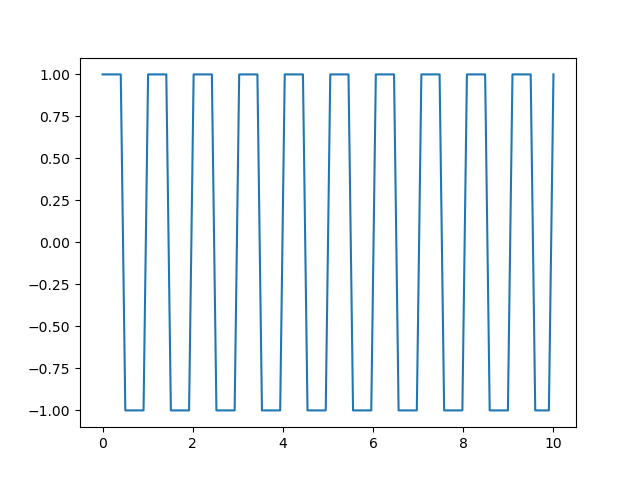

In [29]:
t = np.linspace(0,10, 100)
vin_list = []
for i in t:
    vin_list.append(vin(i))


fig, ax = plt.subplots()
ax.plot(t, vin_list)

In [30]:
# define the differential equation
def f(v, t): # dv_out/dt
    return(1/10*(vin(t) - v))

# define the boundary condition
a = 0.0
b = 10.0
N = 1000
dt = (b-a)/N

# Runge-Kutta 4th order

v = 0.0 # initial condition

tpoints = np.arange(a, b, dt)
vpoints = []

for i in tpoints:
    vpoints.append(v)
    k1 = dt*f(v, i)
    k2 = dt*f(v+1/2*k1, i+1/2*dt)
    k3 = dt*f(v+1/2*k2, i+1/2*dt)
    k4 = dt*f(v+k3, i+dt)
    v = v + (k1+2*k2+2*k3+k4)/6


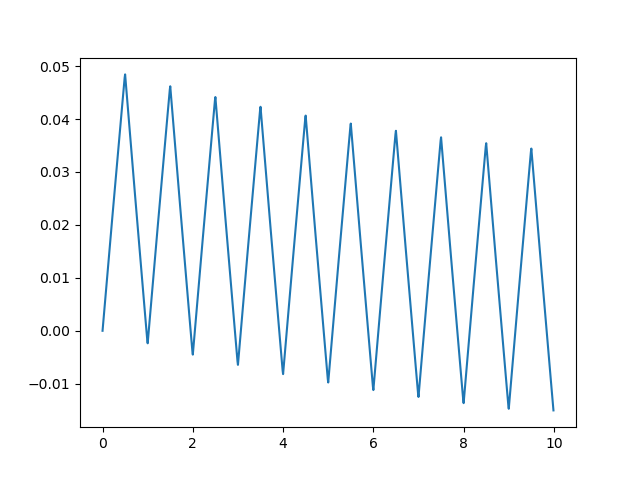

In [31]:
fig0, ax0 = plt.subplots()
ax0.plot(tpoints, vpoints)

ok now to turn toward what we want to do today which is to evaluate a *system of differential equations*. a system of DE's is like a system of equations in that you have to use more than one equation to solve for x, but instead of solving for x, we are solving for an entire function. And with a system, we are solving for *more than one function*. This is very very difficult to do mathematically, but computationally it is very easy. We will start by changing slightly our differential equation function to accept not just y and x or x and t, but a vector *r*, where *r* will be several values all at once. *r* will be a vector representing the values of x and y (and z!) at the same time. Then inside the function *f*, we will unpack this vector *r* and make two or more new differential equations inside, where the calculations will be done, then we will return our vector *r* with all of these values packaged up once again.

In [32]:
# define the differential equation
def f(r, t): # don't forget r is a vector!
    x = r[0]
    y = r[1]
    w = 1.0
    fx = x*y-x  # this is the dx/dt equation!
    fy = y - x*y + np.sin(w*t)**2  # this is the dy/dt equation!
    return(np.array([fx, fy]))

# define the boundary condition
a = 0.0
b = 10.0
N = 1000
dt = (b-a)/N

# Runge-Kutta 4th order

r = np.array([1.0, 1.0]) # initial condition

tpoints = np.arange(a, b, dt)

xpoints = []
ypoints = []

for i in tpoints:
    xpoints.append(r[0])
    ypoints.append(r[1])
    k1 = dt*f(r, i)
    k2 = dt*f(r+1/2*k1, i+1/2*dt)
    k3 = dt*f(r+1/2*k2, i+1/2*dt)
    k4 = dt*f(r+k3, i+dt)
    r = r + (k1+2*k2+2*k3+k4)/6


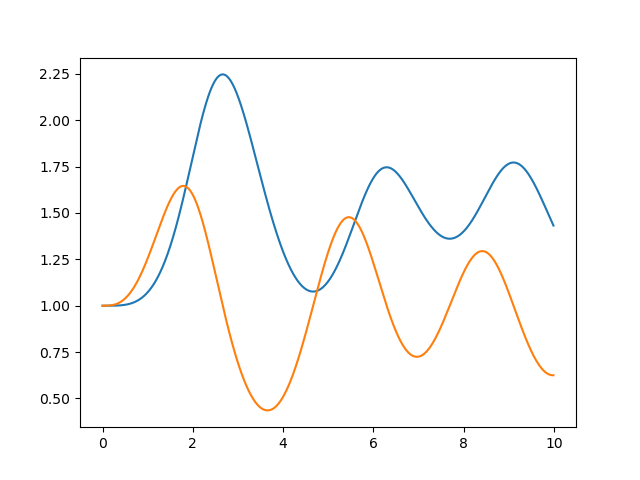

In [33]:
fig1, ax1 =  plt.subplots()
ax1.plot(tpoints, xpoints)
ax1.plot(tpoints, ypoints)

In [43]:
import math

In [48]:
math.trunc(6.8)

6